# CFPB Complaints — Exploratory Data Analysis
**Goal:** Profile the raw CFPB dataset, run a synthetic-vs-real gate check, and filter down to a clean ~40K ticket sample for TriageIQ Phase 1+2.

In [2]:
# ── Cell 0: Setup & Config ─────────────────────────────────────
from pathlib import Path
import json, re, hashlib
from collections import Counter
from datetime import datetime

import numpy as np
import pandas as pd

# CSV is in the same dir as this notebook
PATH  = Path("complaints.csv")
OUT   = Path("data/interim"); OUT.mkdir(parents=True, exist_ok=True)

CHUNK = 250_000   # rows per chunk — keeps memory ~1 GB on the 9 GB file
SEED  = 42        # reproducibility for all sampling

# The free-text column — main NLP input for Phase 2
NARR = "Consumer complaint narrative"

# Structured metadata columns (confirmed to exist in CSV).
# NOTE: "Consumer disputed?" and "Consumer consent provided?" were removed —
#       they don't exist in this CFPB download. Replaced with NARR column.
META = ["Complaint ID", "Date received", "Product", "Sub-product", "Issue",
        "Sub-issue", "Company", "State", "Submitted via",
        "Company response to consumer", "Timely response?",
        "Consumer complaint narrative", "Tags"]

# Read just the header — almost free on a 9 GB file
cols = pd.read_csv(PATH, nrows=0).columns.tolist()
print(f"{len(cols)} columns:")
cols

16 columns:


['Date received',
 'Product',
 'Sub-product',
 'Issue',
 'Sub-issue',
 'Consumer complaint narrative',
 'Company public response',
 'Company',
 'State',
 'ZIP code',
 'Tags',
 'Submitted via',
 'Date sent to company',
 'Company response to consumer',
 'Timely response?',
 'Complaint ID']

## Cell 1 — Chunked metadata load + basic counts

In [3]:
# ── Cell 1: Build metadata table in chunks ─────────────────────
# We can't read 9 GB at once, so we stream in CHUNK-sized pieces,
# extract meta cols + compute has_narrative/n_words per chunk.
parts = []
for chunk in pd.read_csv(PATH, usecols=META, dtype=str, chunksize=CHUNK):
    narr_txt = chunk[NARR].fillna("").str.strip()
    m = chunk[META].copy()
    m["has_narrative"] = narr_txt.ne("")           # bool: does this row have text?
    m["n_words"] = (narr_txt.str.split().str.len()  # word count (0 if no narrative)
                    .where(m["has_narrative"], 0).astype("int32"))
    parts.append(m)

meta = pd.concat(parts, ignore_index=True); del parts  # free chunk memory

# Cast types — datetime for time-series, category for memory savings
meta["Date received"] = pd.to_datetime(meta["Date received"], errors="coerce")
for c in META:
    if c not in ("Complaint ID", "Date received", NARR):
        meta[c] = meta[c].astype("category")

# Persist so we don't re-read 9 GB next time
meta.to_parquet(OUT / "meta.parquet")

# Quick summary
total  = len(meta)
n_narr = int(meta["has_narrative"].sum())
print(f"total rows:        {total:>10,}")
print(f"with narrative:    {n_narr:>10,}  ({n_narr/total:.0%})")

total rows:        17,355,295
with narrative:     3,843,057  (22%)


## Cell 2 — Bias check: narrative vs non-narrative

In [4]:
# ── Cell 2: Compare distributions WITH vs WITHOUT narrative ────
# Why: if narrative rows skew heavily toward one product/channel,
#       our NLP model will inherit that bias.
def share(df, col, top=8):
    """Top-N value shares, normalised."""
    return df[col].value_counts(normalize=True).head(top).round(3)

for col in ["Product", "Submitted via", "Company response to consumer"]:
    cmp = pd.concat(
        {"with_narrative": share(meta[meta.has_narrative], col),
         "without":        share(meta[~meta.has_narrative], col)},
        axis=1).fillna(0.0)
    print(f"\n=== {col} ===")
    display(cmp)


=== Product ===


,with_narrative,without
Product,,
Credit reporting or other personal consumer reports,0.435,0.752
"Credit reporting, credit repair services, or other personal consumer reports",0.210,0.100
Debt collection,0.115,0.054
Checking or savings account,0.049,0.015
Mortgage,0.038,0.023
Credit card,0.033,0.016
"Money transfer, virtual currency, or money service",0.032,0.000
Credit card or prepaid card,0.028,0.007
Credit reporting,0.000,0.008



=== Submitted via ===


,with_narrative,without
Submitted via,,
Web,1.0,0.953
Email,0.0,0.000
Fax,0.0,0.002
Phone,0.0,0.016
Postal mail,0.0,0.008
Referral,0.0,0.021



=== Company response to consumer ===


,with_narrative,without
Company response to consumer,,
Closed with explanation,0.664,0.600
Closed with non-monetary relief,0.306,0.343
Closed with monetary relief,0.026,0.009
Untimely response,0.003,0.002
Closed,0.001,0.001
In progress,0.000,0.044
Closed with relief,0.000,0.000
Closed without relief,0.000,0.001


## Cell 3a — Extract narrative corpus

In [5]:
# ── Cell 3a: Pull out just the narrative text ──────────────────
# Keep only rows where narrative is non-empty. Save as parquet
# for fast reload in later cells and Phase 2.
parts = []
for chunk in pd.read_csv(PATH, usecols=["Complaint ID", NARR],
                         dtype=str, chunksize=CHUNK):
    c = chunk.dropna(subset=[NARR])
    c = c[c[NARR].str.strip().ne("")]
    parts.append(c)

narr = pd.concat(parts, ignore_index=True); del parts
narr.to_parquet(OUT / "narratives.parquet")
print(f"narrative corpus: {len(narr):,} rows  → {OUT/'narratives.parquet'}")

narrative corpus: 3,843,057 rows  → data/interim/narratives.parquet


## Cell 3b — Synthetic-vs-real gate check
Key metrics: word-length variance, exact-dup rate, sentence-length CV, type-token ratio, opener repetition, placeholder check.

In [6]:
# ── Cell 3b: Is this data real or LLM-generated? ───────────────
# Sample up to 100K narratives for speed
gate = narr.sample(min(100_000, len(narr)), random_state=SEED)[NARR]

def norm(t): return re.sub(r"\s+", " ", str(t).strip().lower())
def sents(t): return [s for s in re.split(r"[.!?]+\s", str(t)) if len(s.split()) >= 2]

# Word-count distribution — real data has huge variance
wc = gate.str.split().str.len()
print("words p5/p25/p50/p75/p95:",
      " / ".join(str(int(x)) for x in wc.quantile([.05,.25,.5,.75,.95])))

# Exact duplicate rate via MD5 hashing
hashes  = gate.map(lambda t: hashlib.md5(norm(t).encode()).hexdigest())
dup_rate = 1 - hashes.nunique() / len(hashes)
print(f"exact-dup rate: {dup_rate:.1%}")

# Language detection (optional — needs pip install langdetect)
try:
    from langdetect import detect, DetectorFactory
    DetectorFactory.seed = SEED
    ls = gate.sample(1000, random_state=SEED).map(
        lambda t: (lambda s: detect(s) if s else "??")(str(t)[:500]))
    print("language mix:", dict(ls.value_counts(normalize=True).head(3).round(2)))
except ImportError:
    print("langdetect not installed — pip install langdetect")

# Synthetic-data red flags on a 20K subsample getting the TTR (Type-Token Ratio) -> how much of the words in the narrative are unique 
dsamp = gate.sample(20_000, random_state=SEED)
sl = pd.Series([len(s.split()) for t in dsamp for s in sents(t)])
cv = sl.std() / sl.mean()                       # sentence-length coefficient of variation
tokens = [w for t in dsamp for w in norm(t).split()][:100_000]
ttr = len(set(tokens)) / len(tokens)             # type-token ratio (vocab diversity)
openers = Counter(" ".join(norm(t).split()[:5]) for t in dsamp)
top_open, n_open = openers.most_common(1)[0]     # most repeated 5-word opener
placeholders = int(dsamp.str.contains(
    r"\{[a-z_]+\}|\[(?:PRODUCT|NAME|COMPANY)\]", case=False, regex=True).sum())

print(f"sentence-length CV: {cv:.2f}   (<0.35 suspicious)")
print(f"type-token ratio:   {ttr:.3f}  (<0.08 suspicious)")
print(f"top opener: \u201c{top_open}\u2026\u201d = {n_open/len(dsamp):.1%}  (>5% suspicious)")
print(f"unfilled placeholders: {placeholders}  (must be 0)")

words p5/p25/p50/p75/p95: 22 / 61 / 117 / 214 / 515
exact-dup rate: 19.8%
language mix: {'en': 0.98, 'ca': 0.01, 'vi': 0.0}
sentence-length CV: 0.94   (<0.35 suspicious)
type-token ratio:   0.065  (<0.08 suspicious)
top opener: “in accordance with the fair…” = 3.7%  (>5% suspicious)
unfilled placeholders: 1  (must be 0)


In [7]:
flagged = dsamp[dsamp.str.contains(
    r"\{[a-z_]+\}|\[(?:PRODUCT|NAME|COMPANY)\]", case=False, regex=True)]
print(f"{len(flagged)} texts with placeholder matches:")
for t in flagged.head(5):
    matches = re.findall(r"\{[a-z_]+\}|\[(?:PRODUCT|NAME|COMPANY)\]", t, re.I)
    print(f"  → {matches}  context: ...{t[max(0,t.lower().find(matches[0].lower())-30):t.lower().find(matches[0].lower())+40]}...")


1 texts with placeholder matches:
  → ['{XXXX}', '{XXXX}']  context: ...XX with an alleged balance of {XXXX} and {XXXX} ; both accounts defini...


## Cell 4 — Duplicate anatomy

In [8]:
# ── Cell 4: How bad are duplicates? ────────────────────────────
# Hash every narrative, find groups with identical text.
# Needed to decide dedup strategy for the final sample.
narr["h"] = narr[NARR].map(lambda t: hashlib.md5(norm(t).encode()).hexdigest())
dupes = narr[narr.groupby("h")["h"].transform("size") > 1]
print(f"rows in duplicate groups: {len(dupes):,} ({len(dupes)/len(narr):.1%})")

# Join back to meta for company/date context
d = dupes.merge(meta[["Complaint ID", "Company", "Date received"]], on="Complaint ID")
anatomy = d.groupby("h").agg(
    size=("Complaint ID", "size"),
    companies=("Company", "nunique"),
    days=("Date received", lambda s: s.dt.date.nunique()))
print("\ngroup-size distribution:")
print(anatomy["size"].value_counts().head(10))
print(f"\ncross-company groups (!=1 company): {(anatomy.companies > 1).mean():.0%}")
print(f"largest cluster: {anatomy['size'].max()} copies")
display(anatomy.sort_values("size", ascending=False).head(10))

rows in duplicate groups: 1,589,242 (41.4%)

group-size distribution:
size
2     132402
3     105293
4       7995
5       4086
6       3430
7       1603
8       1267
9       1070
10       664
11       584
Name: count, dtype: int64

cross-company groups (!=1 company): 87%
largest cluster: 30110 copies


,size,companies,days
h,,,
7fbbcc61a1b1785a92b386dd632bbdb5,30110,12,808
e7e3005f8763938464287c43cb200a24,24247,7,753
f2f344b43f80d14c866c299f9a3306f2,18439,18,279
e84d76a1f8417ef6a30ac8b654dcdad2,15803,16,404
a793d6be7cb5f0820aca7ad32e3dcb20,14483,99,458
8e961faa1a7730ffc0935e068b2f8d77,12335,10,99
153020173f4ee91b4b59650f3e37bc91,12211,47,353
0039918a1f6336e23c5d2ba94069162f,10118,4,237
5133f9bb4daefc70aa97e18d4871f959,9997,4,188


## Cell 5 — Redaction analysis

In [9]:
# ── Cell 5: Redaction analysis (sampled for speed) ────────────
# Sample 50K narratives instead of all ~500K — still statistically valid
nsamp = narr.sample(min(50_000, len(narr)), random_state=SEED)

red  = nsamp[NARR].str.count(r"\bX{2,}[X/]*\b")
nw   = nsamp[NARR].str.split().str.len()
dens = red / nw.clip(lower=1)

print(f"narratives with ≥1 redaction: {(red > 0).mean():.0%}")
print("redaction density p50/p90/p99:",
      " / ".join(f"{x:.2f}" for x in dens.quantile([.5, .9, .99])))
print(f"redaction soup (density > 0.30): {(dens > 0.30).mean():.1%}")

print("\n--- worst offender ---")
print(nsamp.loc[dens.idxmax(), NARR][:400])


narratives with ≥1 redaction: 69%
redaction density p50/p90/p99: 0.03 / 0.19 / 0.64
redaction soup (density > 0.30): 5.6%

--- worst offender ---
Thefollowingaccountsthatarelistedonmycreditreportarefraudulent.Ihavetriedtocorrectthisissuemultipletimeswithnosuccesswiththecreditbureau.XXXXXXXXXXXXXXXXXXXXXXXX,$XXXX,openedonXX/XX/XXXX.XXXXXXXX,$XXXX,openedonXX/XX/XXXX.XXXXXXXX,$XXXX,openedonXX/XX/XXXX.XXXX,$XXXX,openedonXX/XX/XXXX.XXXXXXXX$XXXX,openedonXX/XX/XXXXChapterXXXXBankruptcyDischarged,filingdateXX/XX/XXXX,referencenumberXXXX,U.S.Bankru


## Cell 6 — Field audit (nulls + cardinality)

In [10]:
# ── Cell 6: Per-column null rate and unique-value count ────────
# Helps decide which columns are useful features vs too sparse.
mn = meta[meta.has_narrative]
audit = pd.DataFrame({
    "nunique":   {c: mn[c].nunique() for c in META if c != "Complaint ID"},
    "null_rate": {c: round(mn[c].isna().mean(), 3) for c in META if c != "Complaint ID"},
}).sort_values("nunique")
display(audit)

for c in ["Product", "Submitted via", "Issue"]:
    print(f"\n=== top {c} ===")
    print(mn[c].value_counts().head(10))

,nunique,null_rate
Submitted via,1,0.000
Timely response?,2,0.000
Tags,3,0.904
Company response to consumer,6,0.000
Product,21,0.000
State,63,0.004
Sub-product,85,0.014
Issue,173,0.000
Sub-issue,266,0.087
Date received,4143,0.000



=== top Product ===
Product
Credit reporting or other personal consumer reports                             1672115
Credit reporting, credit repair services, or other personal consumer reports     807499
Debt collection                                                                  442850
Checking or savings account                                                      187889
Mortgage                                                                         146706
Credit card                                                                      127743
Money transfer, virtual currency, or money service                               121170
Credit card or prepaid card                                                      108683
Student loan                                                                      62820
Vehicle loan or lease                                                             53278
Name: count, dtype: int64

=== top Submitted via ===
Submitted via
Web            3843057
E

## Cell 7 — Temporal trends

,narrative_share,timely_rate
Date received,,
2011,0.000,0.901
2012,0.000,0.965
2013,0.000,0.988
2014,0.000,0.977
2015,0.325,0.973
2016,0.407,0.966
2017,0.475,0.972
2018,0.460,0.983
2019,0.450,0.985


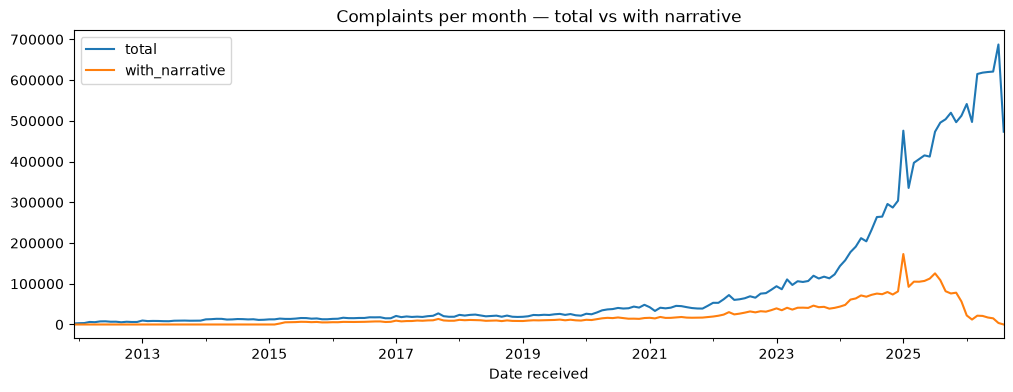

In [11]:
# ── Cell 7: Volume over time ──────────────────────────────────
# Used to pick the date window for the final sample (LO/HI in Cell 8).
monthly = (meta.set_index("Date received")
               .resample("MS")["has_narrative"]
               .agg(total="size", with_narrative="sum"))
monthly.plot(figsize=(12, 4), title="Complaints per month — total vs with narrative");

# Yearly narrative share + timely-response rate
by_year = meta.groupby(meta["Date received"].dt.year).agg(
    narrative_share=("has_narrative", "mean"),
    timely_rate=("Timely response?", lambda s: s.eq("Yes").mean()))
display(by_year.round(3))

## Cell 8 — Build the v2 training set: quality filters + temporal split + case-control sampling

**v2 change.** The old cell applied a per-product cap and sampled 40k rows. That cap flattened the
product mix and, worse, silently tripled the label base rate. v2 drops it: keep the *natural*
product mix, keep **every** positive, and downsample negatives in the training split only.
See `Context/TriageIQ.md` §0.5 and §2.2.

In [ ]:
# ── Cell 8: v2 training set ───────────────────────────────────
# Label  : "Closed with monetary relief"  ->  did this complaint cost the company money?
# Design : 3 decisions, each of which matters
#   1. NO product cap. v1 capped each product at 16k rows, which flattened the mix AND
#      pushed the base rate from 2.16% to 7.5%. Sampling was silently editing the label.
#   2. Temporal split FIRST, then sample. Never the other way round.
#   3. Case-control on TRAIN ONLY: keep all positives, downsample negatives.
#      val/test stay at NATURAL prevalence, because PR-AUC is base-rate sensitive —
#      scoring on a resampled test set would inflate the headline number.
import re, json, hashlib
import numpy as np, pandas as pd, pyarrow.parquet as pq
from datetime import datetime, timezone

SEED        = 42
NEG_PER_POS = 3         # train negatives per positive -> 25% positive
VAL_N       = 80_000    # val  subsample size (natural prevalence)
TEST_N      = 150_000   # test subsample size (natural prevalence)
LO, HI      = "2022-01-01", "2024-12-31"
MIN_WORDS, MAX_REDACT, MAX_CLUSTER = 20, 0.30, 25
VAL_START, TEST_START = "2023-10-01", "2024-01-01"

KEEP = ["Complaint ID","Date received","Product","Sub-product","Issue","Sub-issue",
        "Company","State","Tags","Company response to consumer",NARR,"has_narrative","n_words"]
d = pq.read_table(OUT/"meta.parquet", columns=KEEP,
                  filters=[("has_narrative","==",True)]).to_pandas()
d["Date received"] = pd.to_datetime(d["Date received"])

# ---- quality funnel (no product cap) ----
funnel = {"narratives_all": len(d)}
d = d[d["Date received"].between(LO, HI)];        funnel["date_window"] = len(d)
d = d[d.n_words >= MIN_WORDS];                    funnel["min_words"]   = len(d)
dens = d[NARR].str.count(r"\bX{2,}[X/]*\b") / d.n_words.clip(lower=1)
d = d[dens < MAX_REDACT].copy();                  funnel["redaction"]   = len(d)
d["h"] = d[NARR].map(lambda t: hashlib.md5(norm(t).encode()).hexdigest())
d = d[d.groupby("h")["h"].transform("size") <= MAX_CLUSTER].copy()
funnel["template_clusters"] = len(d)

d["y"] = (d["Company response to consumer"].astype(str) == "Closed with monetary relief").astype(int)
funnel["eligible_pool"]      = len(d)
funnel["eligible_positives"] = int(d.y.sum())

# ---- temporal split BEFORE any sampling ----
d["split"] = np.where(d["Date received"] < VAL_START,  "train",
             np.where(d["Date received"] < TEST_START, "val", "test"))
print("natural prevalence by split:")
for s in ["train","val","test"]:
    g = d[d.split == s]
    print(f"  {s:<6}{len(g):>9,} rows{int(g.y.sum()):>8,} pos  {g.y.mean():>7.2%}")

# ---- case-control on TRAIN only ----
tr  = d[d.split == "train"]
pos, neg = tr[tr.y == 1], tr[tr.y == 0]
n_neg    = min(len(neg), NEG_PER_POS * len(pos))
neg_frac = n_neg / len(neg)                       # needed to undo the resampling later
train = pd.concat([pos, neg.sample(n_neg, random_state=SEED)])
val   = d[d.split == "val" ].sample(min(VAL_N,  (d.split=="val" ).sum()), random_state=SEED)
test  = d[d.split == "test"].sample(min(TEST_N, (d.split=="test").sum()), random_state=SEED)

final = pd.concat([train, val, test]).sample(frac=1, random_state=SEED).reset_index(drop=True)
for s in ["train","val","test"]:
    funnel[f"{s}_rows"] = int((final.split == s).sum())
funnel["final_rows"] = len(final)

print("\nafter sampling:")
for s in ["train","val","test"]:
    g = final[final.split == s]
    print(f"  {s:<6}{len(g):>9,} rows{int(g.y.sum()):>8,} pos  {g.y.mean():>7.2%}")
print(f"\nnegative keep-fraction (train): {neg_frac:.6f}")
print(f"recalibration logit offset log(p) = {np.log(neg_frac):.4f}")

final.drop(columns=["h","has_narrative"]).to_parquet(OUT/"triageiq_training_v2.parquet")
manifest = {
    "created": datetime.now(timezone.utc).isoformat(), "seed": SEED, "schema_version": "v2",
    "label": "Company response to consumer == 'Closed with monetary relief'",
    "filters": {"date":[LO,HI], "min_words":MIN_WORDS, "max_redaction_density":MAX_REDACT,
                "max_dup_cluster":MAX_CLUSTER, "product_cap":None},
    "split": {"train":f"<{VAL_START}", "val":f"{VAL_START}..{TEST_START}", "test":"2024"},
    "sampling": {"train":f"case-control: ALL positives + {NEG_PER_POS}x negatives",
                 "negative_keep_fraction":neg_frac,
                 "recalibration_logit_offset":float(np.log(neg_frac)),
                 "val_test":"uniform subsample at NATURAL prevalence"},
    "funnel": funnel,
    "note": ("Training set only. Features are computed in Postgres over ALL 4,826,564 "
             "window complaints (two-tier rule) and joined by Complaint ID."),
}
json.dump(manifest, open(OUT/"triageiq_training_v2.manifest.json","w"), indent=2)
print("\n" + json.dumps(funnel, indent=2))
print("\nproduct mix (natural, no cap):")
print(final["Product"].value_counts(normalize=True).round(3).head(8))


## Cell 9 — Generate docs/data_profile.md

In [ ]:
# ── Cell 9: write docs/data_profile.md ────────────────────────
# Auto-generated from the cells above. Regenerate after any funnel change.
from pathlib import Path
tr_r, va_r, te_r = funnel["train_rows"], funnel["val_rows"], funnel["test_rows"]
tr = final[final.split=="train"]; va = final[final.split=="val"]; te = final[final.split=="test"]

profile = f"""# CFPB Data Profile — TriageIQ **v2**
Generated: {datetime.now(timezone.utc).date()} · seed {SEED} · label = monetary relief

> v2 supersedes the v1 profile (40k product-capped sample). The product cap was removed: it
> flattened the product mix and silently tripled the label base rate. See `Context/TriageIQ.md` §0.5.

## Corpus
| | |
|---|---|
| raw rows | {17_355_295:,} (9.2 GB) |
| with narrative | {funnel['narratives_all']:,} |
| window | {LO} .. {HI} |
| all complaints in window | {4_826_564:,} |

## Funnel — quality filters only, no product cap
| stage | rows |
|---|---|
| narratives (all time) | {funnel['narratives_all']:,} |
| date window | {funnel['date_window']:,} |
| >= {MIN_WORDS} words | {funnel['min_words']:,} |
| redaction density < {MAX_REDACT} | {funnel['redaction']:,} |
| dup cluster <= {MAX_CLUSTER} | {funnel['template_clusters']:,} |
| **eligible pool** | **{funnel['eligible_pool']:,}** |
| eligible positives | {funnel['eligible_positives']:,} ({funnel['eligible_positives']/funnel['eligible_pool']:.2%}) |

The filters are **not** label-neutral, and that is fine: they retain {funnel['eligible_positives']/35_375:.1%}
of all positives while removing {1-funnel['eligible_pool']/funnel['date_window']:.0%} of rows. Base rate
rises 2.16% -> {funnel['eligible_positives']/funnel['eligible_pool']:.2%} because the dup-cluster filter
strips templated credit-reporting complaints, which almost never end in monetary relief.

## Splits — temporal, then sampled
| split | period | rows | positives | rate |
|---|---|---|---|---|
| train | < {VAL_START} | {tr_r:,} | {int(tr.y.sum()):,} | {tr.y.mean():.2%} (case-control) |
| val | {VAL_START} .. {TEST_START} | {va_r:,} | {int(va.y.sum()):,} | {va.y.mean():.2%} (natural) |
| test | 2024 | {te_r:,} | {int(te.y.sum()):,} | {te.y.mean():.2%} (natural) |

Train keeps **every** positive and downsamples negatives (keep-fraction {neg_frac:.4f}).
Recalibrate predictions with logit offset **{np.log(neg_frac):.4f}** to return to the true prior.
val/test are left at natural prevalence — PR-AUC is base-rate sensitive, so scoring on a resampled
test set would inflate the headline number.

Base rate drifts down over time (2022 3.38% / 2023 3.49% / 2024 2.79%), so the test split is
genuinely harder than train. That is the honest direction for a temporal split.

## Gate verdict — data is real
| metric | raw | threshold |
|---|---|---|
| exact-dup rate | {dup_rate:.1%} | — |
| sentence-length CV | {cv:.2f} | < 0.35 suspicious |
| type-token ratio | {ttr:.3f} | < 0.08 suspicious |
| top opener | {n_open/len(dsamp):.1%} | > 5% suspicious |

Top opener is FCRA boilerplate ("in accordance with the fair credit reporting act") that real
consumers copy-paste from credit-repair forums — evidence *for* authenticity, not against.

**Two false alarms, resolved — do not re-litigate.**
1. "Placeholders" are `{{XXXX}}`, CFPB's currency-redaction convention. The detector regex
   `\\{{[a-z_]+\\}}` ran with `case=False`, so `[a-z_]` matched uppercase X. Real LLM placeholders: 0.
2. "40+ char words" are URLs — 0.26% of rows, 0 documents materially corrupted. The genuine
   whitespace-collapse cases were already removed by the redaction filter, which cleaned a defect
   it was not aimed at.

## Field decisions for the DDL
Sizes are frame **F1** (all 4,826,564 window complaints). Source of truth: `Context/FACTS.md`.
Schema reasoning: `Context/schema_explanation.md`.

| column | decision |
|---|---|
| `Consumer complaint narrative` | primary model input; lives in its own extension table |
| `Complaint ID` | PK — unique across all 4,826,564 window rows; stored as text, **cast to BIGINT** |
| `Date received` | day granularity only; 43.46% of company-days hold >1 complaint -> `TriageIQ.md` §1.4a |
| `Company` | 4,950 distinct; 53 in name-collision groups -> surrogate key, collisions mapped to one id |
| `Product` / `Sub-product` | **14 / 58** in window. Sub-products repeat across products -> child unique on (product, sub-product). Products renamed/split ~2023-08-24 |
| `Issue` / `Sub-issue` | **93 / 212** in window. Sub-issue 2.53% null (F1) / 4.17% (F2) -> `'(not specified)'` member. Issue is independent of Product |
| `State` | **61** in window, 0.23% null |
| `Tags` | **open** — 94.49% null in F1 but 87.82% in the training set |
| `Submitted via` | **open** — 1 value in narrative rows, **5 in F1** (Phone, Referral, Postal mail…). Dead for the model, not for volume features |
| `ZIP code` | **drop** — 100% populated but 19% redacted (`XXXXX`, `604XX`); thousands of levels; `State` alone scores only AUC 0.549, so ZIP adds noise + PII surface |
| `Company response to consumer` | **the label**. Post-intake — never a feature. 19 NULLs in F1 -> excluded, not negative |
| `Date sent to company`, `Timely response?`, `Company public response` | **leakage** — post-intake, event-log only. `Date sent to company` is **not in `meta.parquet`** yet |

## Two-tier rule
This training set is **not** the feature population. Aggregates are computed in Postgres over all
{4_826_564:,} window complaints (including the ~3.2M with no narrative, which still count toward
company volume). Only rows that *have* text can be training rows.
"""
Path("docs").mkdir(exist_ok=True)
Path("docs/data_profile.md").write_text(profile)
print(profile[:1500])


In [ ]:
# ── Cell 10: Re-run diversity gate on the v2 training set ─────
# Compare against raw-data results (Cell 3b) to confirm
# the funnel filters didn't accidentally make the data worse.
# NOTE: v2 has no product cap, so the mix here is the NATURAL CFPB mix.

final_df = pd.read_parquet(OUT / "triageiq_training_v2.parquet")
gate2 = final_df[NARR]

# Word-length distribution
wc2 = gate2.str.split().str.len()
print("words p5/p25/p50/p75/p95:",
      " / ".join(str(int(x)) for x in wc2.quantile([.05,.25,.5,.75,.95])))

# Exact-dup rate
hashes2 = gate2.map(lambda t: hashlib.md5(norm(t).encode()).hexdigest())
dup_rate2 = 1 - hashes2.nunique() / len(hashes2)
print(f"exact-dup rate: {dup_rate2:.1%}")

# Sentence-length CV
dsamp2 = gate2.sample(min(20_000, len(gate2)), random_state=SEED)
sl2 = pd.Series([len(s.split()) for t in dsamp2 for s in sents(t)])
cv2 = sl2.std() / sl2.mean()

# TTR
tokens2 = [w for t in dsamp2 for w in norm(t).split()][:100_000]
ttr2 = len(set(tokens2)) / len(tokens2)

# Top opener
openers2 = Counter(" ".join(norm(t).split()[:5]) for t in dsamp2)
top_open2, n_open2 = openers2.most_common(1)[0]

# Placeholders
placeholders2 = int(dsamp2.str.contains(
    r"\{[a-z_]+\}|\[(?:PRODUCT|NAME|COMPANY)\]", case=False, regex=True).sum())

print(f"\nsentence-length CV: {cv2:.2f}   (raw was {cv:.2f})")
print(f"type-token ratio:   {ttr2:.3f}  (raw was {ttr:.3f})")
print(f"top opener: \u201c{top_open2}\u2026\u201d = {n_open2/len(dsamp2):.1%}")
print(f"placeholders: {placeholders2}")

print(f"\n{'─'*50}")
print(f"{'Metric':<25} {'Raw':>8} {'v2 train set':>13}")
print(f"{'─'*50}")
print(f"{'dup rate':<25} {dup_rate:>8.1%} {dup_rate2:>10.1%}")
print(f"{'sentence CV':<25} {cv:>8.2f} {cv2:>10.2f}")
print(f"{'TTR':<25} {ttr:>8.3f} {ttr2:>10.3f}")
print(f"{'top opener %':<25} {n_open/len(dsamp):>8.1%} {n_open2/len(dsamp2):>10.1%}")
print(f"{'placeholders':<25} {placeholders:>8} {placeholders2:>10}")


In [15]:
# Flag narratives with suspiciously long "words" (missing spaces)
long_words = df[NARR].str.findall(r"\S{40,}")
has_long = long_words.str.len() > 0
print(f"rows with 40+ char words: {has_long.sum():,} ({has_long.mean():.1%})")


rows with 40+ char words: 1,659 (0.2%)
